# Satellite Data for Air Quality

**Part 1 of the AQ Satellite Integration module.**

This notebook constitutes your first hands-on engagement with real satellite-derived air-quality data downloaded from the **Copernicus Atmosphere Data Store (ADS)**. The dataset under investigation is **PM₂.₅** over **Croatia**.

Upon completion of this notebook, you will be able to:

1. Open a satellite or atmospheric NetCDF file and interpret its internal structure.
2. Select the appropriate scientific variable for analysis.
3. Visualise the data on a map.
4. Extract values at a list of ground-station locations.
5. Save the results as a tidy table, prepared for subsequent merging with ground measurements.


## Preparatory Setup

You must prepare the data files **before** executing this notebook, because the workflow operates on real data fetched from Copernicus.

**Procedure (required only once):**

1. Create a free account at <https://ads.atmosphere.copernicus.eu/>.
2. Copy your Personal Access Token from the "Your profile" section.
3. Save it to `~/.cdsapirc` in the following form:

   ```
   url: https://ads.atmosphere.copernicus.eu/api
   key: PASTE-YOUR-TOKEN-HERE
   ```

4. Accept the licence at:
   <https://ads.atmosphere.copernicus.eu/datasets/cams-europe-air-quality-reanalyses>
5. From a terminal opened in the `scripts/` folder, execute:

   ```
   pip install -r requirements.txt
   python download_cams_data.py
   ```

   This command creates `data/cams_pm25_croatia.nc`, the CAMS PM₂.₅ grid over Croatia.

6. **Urban Atlas - manual download required:**

   For the Urban Atlas files, follow the steps below:

   a. Log in at <https://land.copernicus.eu/en/user-corner/my-account>.  
   b. Search for **"Urban Atlas Land Cover/Land Use 2021"** and select the Zagreb tile  
      (`CLMS_UA_LCU_S2021_V025ha_HR001L2_GRAD_ZAGREB_03035_V01_R01_20250321`, FGB format, approximately 192 MB).  
   c. Submit the download request. CLMS will send an electronic mail notification when the ZIP archive is ready.  
   d. Download the ZIP archive (any filename, any location), and then execute:

   ```
   python prepare_urban_atlas.py --zip C:\path\to\downloaded.zip
   ```

   This command creates `data/CLMS_UA_LCU_S2021_V025ha_HR001L2_GRAD_ZAGREB_03035_V01_R01_20250321.fgb`.


## Background

### Data

The Copernicus Atmosphere Monitoring Service (**CAMS**) produces gridded air-quality data by combining three sources:

- **Satellite observations** (Sentinel-5P TROPOMI, IASI, and related instruments),
- **Ground measurements** reported by EU Member States in near-real time,
- **A chemistry-transport model** that fills the spatial and temporal gaps.

This combination is known as **data assimilation**. The result is a gap-free, regular latitude-longitude grid of pollutant concentrations. Such a product is substantially easier to use than raw satellite swaths, yet it remains rooted in real satellite observations.

### File Format

CAMS files are distributed as **NetCDF** (`.nc`). NetCDF stores labelled, multi-dimensional arrays. The notebook opens such files using the **`xarray`** library, which presents them as a structured dictionary of arrays accompanied by metadata.

A typical CAMS file possesses four dimensions:

- `time` (one entry per hour requested),
- `level` (vertical height layer; the surface level will be used),
- `latitude`,
- `longitude`.


## Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

In [4]:
import sys
from pathlib import Path

import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import geopandas as gpd
import numpy as np
import pandas as pd


In [5]:
_scripts_root = Path.cwd().parent.parent / "scripts"
if not _scripts_root.exists():
    _scripts_root = Path.cwd().parent / "scripts" 
sys.path.insert(0, str(_scripts_root))
sys.path.insert(0, str(_scripts_root / "part1_satellite_aq"))

import satellite_extract_points as sxp
import satellite_to_table as stt
from utils import _load_data 

## Verification of the Downloaded Data

The notebook expects a data file located at `data/cams_pm25_croatia.nc`. If this file is not present, the cell below will fail; consult the preparatory setup at the top of this notebook for instructions on how to create it.


In [6]:
DATA_PATH = Path("../../data/cams_pm25_croatia.nc")

size_mb = DATA_PATH.stat().st_size / (1024 * 1024)
print(f"Found: {DATA_PATH}  ({size_mb:.2f} MB)")


Found: ..\..\data\cams_pm25_croatia.nc  (9.68 MB)


## Opening the File

Small helper function, `_load_data`, was imported from `scripts/utils.py`. This function is a thin wrapper around `xr.open_dataset()` that additionally knows how to unpack CDS-style ZIP bundles and automatically selects the appropriate backend (`netcdf4` for classic CAMS files, `h5netcdf` for ERA5 HDF5 bundles). For a plain `.nc` file, it behaves identically to `xr.open_dataset()`.

The object returned is an `xarray.Dataset`.

In [7]:
ds = _load_data(DATA_PATH)
ds

<xarray.Dataset> Size: 10MB
Dimensions:  (time: 720, lat: 50, lon: 70)
Coordinates:
  * time     (time) datetime64[ns] 6kB 2024-06-01 ... 2024-06-30T23:00:00
  * lat      (lat) float64 400B 42.05 42.15 42.25 42.35 ... 46.75 46.85 46.95
  * lon      (lon) float64 560B 13.05 13.15 13.25 13.35 ... 19.75 19.85 19.95
Data variables:
    pm2p5    (time, lat, lon) float32 10MB 4.605 4.225 3.476 ... 10.84 10.56
Attributes:
    Conventions:  CF-1.7
    Title:        CAMS European air quality interim reanalysis
    Provider:     COPERNICUS European air quality service
    Production:   COPERNICUS Atmosphere Monitoring Service

- **Dimensions** indicate the shape of each axis (number of timesteps, number of grid points, number of vertical levels).
- **Coordinates** are the actual values along each dimension (the latitude and longitude numbers, the timestamps).
- **Data variables** are the scientific fields themselves (PM₂.₅ concentration).
- **Attributes** are the global metadata describing the whole file.

This four-part pattern - dimensions, coordinates, variables, attributes - is identical for **most** NetCDF air-quality product.


## Inspecting Each Component

In [8]:
print("Dimensions:")
for name, size in ds.sizes.items():
    print(f"  {name}: {size}")

Dimensions:
  time: 720
  lat: 50
  lon: 70


In [9]:
print("Data variables:")
for name in ds.data_vars:
    var = ds[name]
    units = var.attrs.get("units", "?")
    long_name = var.attrs.get("long_name", var.attrs.get("standard_name", "?"))
    print(f"  {name}: shape={var.shape}, units={units}")
    print(f"      long_name: {long_name}")

Data variables:
  pm2p5: shape=(720, 50, 70), units=µg/m3
      long_name: mass concentration of particulate matter with d < 2.5µm


In [10]:
print("Global attributes:")
for key, value in ds.attrs.items():
    text = str(value)
    if len(text) > 100:
        text = text[:97] + "..."
    print(f"  {key}: {text}")

Global attributes:
  Conventions: CF-1.7
  Title: CAMS European air quality interim reanalysis
  Provider: COPERNICUS European air quality service
  Production: COPERNICUS Atmosphere Monitoring Service


## Selecting the Target Variable

In any realistic workflow, the first decision concerns which pollutant to analyse. Because PM₂.₅ was requested at download time, the dataset contains exactly one scientific variable. The cell below auto-detects its name, so that the remainder of the notebook continues to function even if CAMS renames the variable in a future release.

In [11]:
variable_name = list(ds.data_vars)[0]
print(f"Target variable: {variable_name!r}")

target = ds[variable_name]
print(target)

Target variable: 'pm2p5'
<xarray.DataArray 'pm2p5' (time: 720, lat: 50, lon: 70)> Size: 10MB
array([[[ 4.6045403 ,  4.2248363 ,  3.4761417 , ...,  7.4960938 ,
          7.4788475 ,  8.031312  ],
        [ 5.1057177 ,  4.784595  ,  3.9058127 , ...,  6.5       ,
          6.578125  ,  7.1148705 ],
        [ 4.9682007 ,  4.734681  ,  4.3437147 , ...,  7.078125  ,
          6.4730716 ,  6.492724  ],
        ...,
        [ 1.1992188 ,  0.9718575 ,  1.0595524 , ...,  3.7392576 ,
          3.75      ,  3.8125    ],
        [ 1.020022  ,  0.6943083 ,  0.74047923, ...,  3.8525388 ,
          3.881836  ,  3.9179685 ],
        [ 0.78706145,  0.7512438 ,  0.7707223 , ...,  3.9541013 ,
          3.975586  ,  4.5722656 ]],

       [[ 3.8436952 ,  3.5095675 ,  3.1953125 , ...,  7.2353516 ,
          7.457614  ,  7.317383  ],
        [ 3.7584326 ,  3.6445146 ,  3.4433594 , ...,  6.648437  ,
          6.741534  ,  7.59375   ],
        [ 4.4813614 ,  4.6483493 ,  3.9566507 , ...,  6.384569  ,
          

In [13]:
units = target.attrs.get("units", "?")
print(f"Min:    {float(target.min()):.3f}  {units}")
print(f"Max:    {float(target.max()):.3f}  {units}")
print(f"Mean:   {float(target.mean()):.3f}  {units}")
print(f"Median: {float(target.median()):.3f}  {units}")

Min:    0.452  µg/m3
Max:    50.088  µg/m3
Mean:   9.071  µg/m3
Median: 7.983  µg/m3


## Selecting the Surface Layer

CAMS provides several height levels stacked along a `level` dimension. For comparison we will use the lowest level, which is (`level=0` in the index).

In [14]:
if "level" in target.dims:
    surface = target.isel(level=0).drop_vars("level", errors="ignore")
else:
    surface = target

target = surface
print(f"After surface selection: dims = {dict(target.sizes)}")

After surface selection: dims = {'time': 720, 'lat': 50, 'lon': 70}


## Visual Inspection of the Data

You should always plot your data before trusting it. The xarray library provides a one-line `.plot()` method that produces an appropriate visualisation for two-dimensional arrays.

The following cell plots the first available time step. If the file contains several hours, you may modify the index to inspect other timestamps.

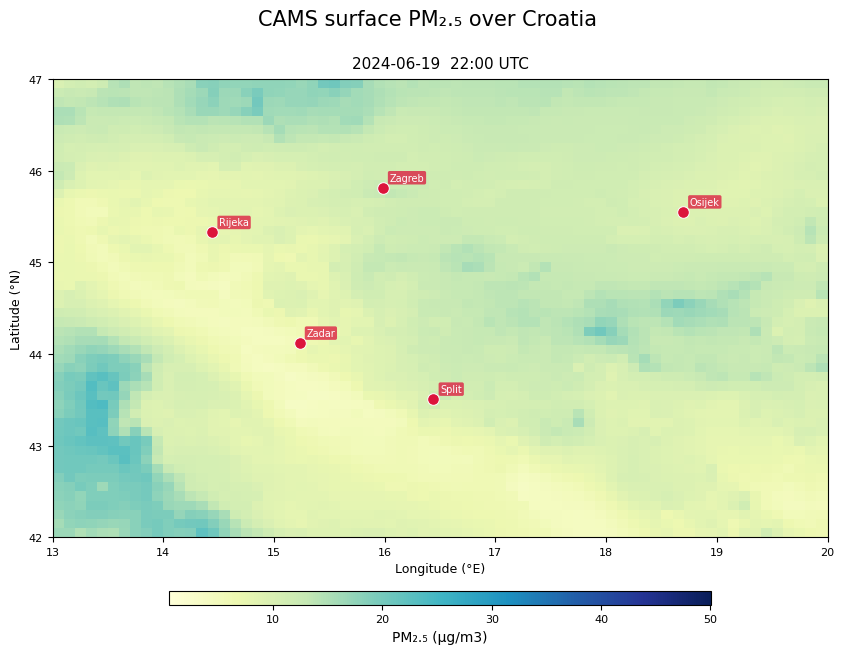

In [16]:
units = target.attrs.get("units", "?")
vmin  = float(target.min())
vmax  = float(target.max())
CMAP  = "YlGnBu"
norm  = mcolors.Normalize(vmin=vmin, vmax=vmax)

_stations = pd.read_csv("../../data/stations_example.csv")

lat_name = "lat" if "lat" in target.coords else "latitude"
lon_name = "lon" if "lon" in target.coords else "longitude"

rng = np.random.default_rng()
i = int(rng.integers(0, target.sizes["time"]))

snapshot = target.isel(time=i)
if float(snapshot[lon_name].max()) > 180:
    snapshot = snapshot.assign_coords(
        {lon_name: ((snapshot[lon_name] + 180) % 360) - 180}
    )
snapshot = snapshot.sortby([lat_name, lon_name])

fig, ax = plt.subplots(figsize=(10, 7))

snapshot.plot(ax=ax, cmap=CMAP, vmin=vmin, vmax=vmax, add_colorbar=False)

ax.scatter(
    _stations["lon"], _stations["lat"],
    color="crimson", edgecolors="white", linewidths=0.7,
    s=70, zorder=6,
)
for _, row in _stations.iterrows():
    ax.annotate(
        row["station_name"],
        xy=(row["lon"], row["lat"]),
        xytext=(5, 5), textcoords="offset points",
        fontsize=7, color="white",
        bbox=dict(boxstyle="round,pad=0.18", fc="crimson", alpha=0.75, lw=0),
        zorder=7,
    )

time_val = snapshot.time.values
time_str = (
    pd.Timestamp(time_val).strftime("%Y-%m-%d  %H:%M UTC")
    if hasattr(time_val, "dtype") and np.issubdtype(time_val.dtype, np.datetime64)
    else str(time_val)
)
ax.set_title(time_str, fontsize=11, pad=8)
ax.set_xlabel("Longitude (°E)", fontsize=9, labelpad=4)
ax.set_ylabel("Latitude (°N)", fontsize=9, labelpad=4)
ax.tick_params(labelsize=8)

sm = cm.ScalarMappable(cmap=CMAP, norm=norm)
sm.set_array([])
cbar = fig.colorbar(
    sm, ax=ax, orientation="horizontal",
    fraction=0.05, pad=0.1, aspect=40, shrink=0.7,
)
cbar.set_label(f"PM₂.₅ ({units})", fontsize=10)
cbar.ax.tick_params(labelsize=8)

fig.suptitle("CAMS surface PM₂.₅ over Croatia", fontsize=15, y=0.98)
plt.show()


## Extracting Pixel Values at Station Locations

At this stage, a satellite-derived grid and a list of monitoring stations are both available. The objective is to obtain one value per station: the CAMS PM₂.₅ estimate at the location of each one.

The notebook uses the helper module **`satellite_extract_points.py`**, which resides alongside this notebook. It offers two extraction methods:

- **`extract_nearest`** - selects the single closest pixel.
- **`extract_buffer_mean`** - averages all pixels within a given radius (in kilometres).

The cells below load the five Croatian cities and apply both methods for comparison.


In [17]:
stations = sxp.load_stations("../../data/stations_example.csv")
stations

,location_id,station_name,lat,lon,country
0,ZAGREB01,Zagreb,45.8150,15.9819,HR
1,SPLIT01,Split,43.5081,16.4402,HR
2,RIJEKA01,Rijeka,45.3271,14.4422,HR
3,OSIJEK01,Osijek,45.5511,18.6939,HR
4,ZADAR01,Zadar,44.1194,15.2314,HR


In [18]:
# Method A: nearest pixel.
nearest_df = sxp.extract_nearest(
    ds=ds,
    variable=variable_name,
    stations=stations,
)
nearest_df

,time,location_id,lat,lon,variable,value,source,method
0,2024-06-01 00:00:00,ZAGREB01,45.8150,15.9819,pm2p5,4.671875,satellite,nearest
1,2024-06-01 00:00:00,SPLIT01,43.5081,16.4402,pm2p5,7.304688,satellite,nearest
2,2024-06-01 00:00:00,RIJEKA01,45.3271,14.4422,pm2p5,3.243164,satellite,nearest
3,2024-06-01 00:00:00,OSIJEK01,45.5511,18.6939,pm2p5,4.585938,satellite,nearest
4,2024-06-01 00:00:00,ZADAR01,44.1194,15.2314,pm2p5,5.404819,satellite,nearest
...,...,...,...,...,...,...,...,...
3595,2024-06-30 23:00:00,ZAGREB01,45.8150,15.9819,pm2p5,10.224613,satellite,nearest
3596,2024-06-30 23:00:00,SPLIT01,43.5081,16.4402,pm2p5,11.257812,satellite,nearest
3597,2024-06-30 23:00:00,RIJEKA01,45.3271,14.4422,pm2p5,13.114057,satellite,nearest
3598,2024-06-30 23:00:00,OSIJEK01,45.5511,18.6939,pm2p5,12.722656,satellite,nearest


In [19]:
# Method B: 25 km buffer average (smoother).
buffer_df = sxp.extract_buffer_mean(
    ds=ds,
    variable=variable_name,
    stations=stations,
    radius_km=25.0,
)
buffer_df

,time,location_id,lat,lon,variable,value,source,method
0,2024-06-01 00:00:00,ZAGREB01,45.8150,15.9819,pm2p5,4.316056,satellite,buffer_mean_25.0km
1,2024-06-01 01:00:00,ZAGREB01,45.8150,15.9819,pm2p5,4.295335,satellite,buffer_mean_25.0km
2,2024-06-01 02:00:00,ZAGREB01,45.8150,15.9819,pm2p5,4.793865,satellite,buffer_mean_25.0km
3,2024-06-01 03:00:00,ZAGREB01,45.8150,15.9819,pm2p5,5.005043,satellite,buffer_mean_25.0km
4,2024-06-01 04:00:00,ZAGREB01,45.8150,15.9819,pm2p5,4.903940,satellite,buffer_mean_25.0km
...,...,...,...,...,...,...,...,...
3595,2024-06-30 19:00:00,ZADAR01,44.1194,15.2314,pm2p5,11.687019,satellite,buffer_mean_25.0km
3596,2024-06-30 20:00:00,ZADAR01,44.1194,15.2314,pm2p5,11.880688,satellite,buffer_mean_25.0km
3597,2024-06-30 21:00:00,ZADAR01,44.1194,15.2314,pm2p5,11.914473,satellite,buffer_mean_25.0km
3598,2024-06-30 22:00:00,ZADAR01,44.1194,15.2314,pm2p5,11.990070,satellite,buffer_mean_25.0km


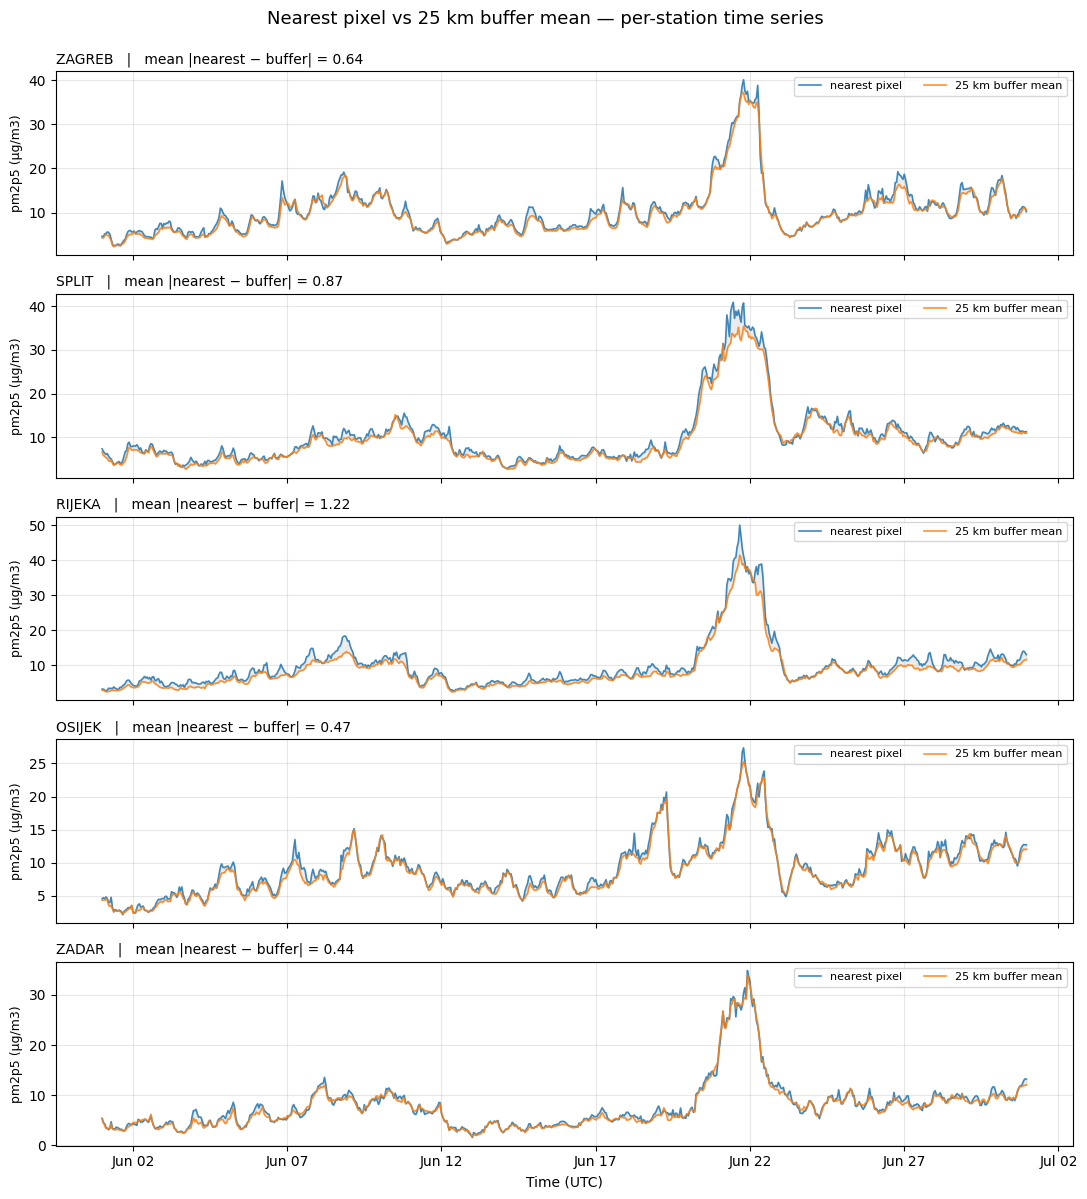

In [20]:
stations_order = nearest_df["location_id"].drop_duplicates().tolist()
units_label = nearest_df["variable"].iloc[0] + f" ({ds[variable_name].attrs.get('units', '?')})"

fig, axes = plt.subplots(5, 1, figsize=(11, 12), sharex=True)
fig.suptitle("Nearest pixel vs 25 km buffer mean — per-station time series",
             fontsize=13, y=0.995)

for ax, loc in zip(axes, stations_order):
    near = nearest_df[nearest_df["location_id"] == loc].sort_values("time")
    buff = buffer_df[buffer_df["location_id"] == loc].sort_values("time")

    ax.plot(near["time"], near["value"], color="tab:blue",
            linewidth=1.2, alpha=0.85, label="nearest pixel")
    ax.plot(buff["time"], buff["value"], color="tab:orange",
            linewidth=1.2, alpha=0.85, label="25 km buffer mean")

    ax.fill_between(
        near["time"].values,
        near["value"].values,
        buff["value"].values,
        color="grey", alpha=0.15,
    )

    diff = near["value"].values - buff["value"].values
    mean_abs_diff = float(abs(diff).mean())
    ax.set_title(
        f"{loc.replace('01', '')}   |   mean |nearest − buffer| = {mean_abs_diff:.2f}",
        fontsize=10, loc="left",
    )
    ax.set_ylabel(units_label, fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper right", fontsize=8, ncol=2)

axes[-1].set_xlabel("Time (UTC)")
axes[-1].xaxis.set_major_locator(mdates.DayLocator(interval=5))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))

plt.tight_layout()
plt.show()


## Saving the Canonical Long-Format Table

The final step is to save the extracted values as a tidy CSV file with the columns expected by the remainder of the pipeline. The helper module **`satellite_to_table.py`** performs the cleanup and writes a small metadata sidecar file, so that units and provenance are preserved.

In [21]:
out_csv = stt.write_canonical_output(
    extracted_df=nearest_df,
    ds=ds,
    variable=variable_name,
    method="nearest",
    output_csv="../../data/outputs/satellite_pm25_nearest.csv",
)

print(f"Wrote:  {out_csv}")
print(f"Wrote:  {out_csv.with_suffix('.meta.txt')}")


Wrote:  ..\..\data\outputs\satellite_pm25_nearest.csv
Wrote:  ..\..\data\outputs\satellite_pm25_nearest.meta.txt


In [22]:
final = pd.read_csv("../../data/outputs/satellite_pm25_nearest.csv")
final


,time,location_id,lat,lon,variable,value,source,method
0,2024-06-01 00:00:00,ZAGREB01,45.8150,15.9819,pm2p5,4.671875,satellite,nearest
1,2024-06-01 00:00:00,SPLIT01,43.5081,16.4402,pm2p5,7.304688,satellite,nearest
2,2024-06-01 00:00:00,RIJEKA01,45.3271,14.4422,pm2p5,3.243164,satellite,nearest
3,2024-06-01 00:00:00,OSIJEK01,45.5511,18.6939,pm2p5,4.585938,satellite,nearest
4,2024-06-01 00:00:00,ZADAR01,44.1194,15.2314,pm2p5,5.404820,satellite,nearest
...,...,...,...,...,...,...,...,...
3595,2024-06-30 23:00:00,ZAGREB01,45.8150,15.9819,pm2p5,10.224613,satellite,nearest
3596,2024-06-30 23:00:00,SPLIT01,43.5081,16.4402,pm2p5,11.257812,satellite,nearest
3597,2024-06-30 23:00:00,RIJEKA01,45.3271,14.4422,pm2p5,13.114057,satellite,nearest
3598,2024-06-30 23:00:00,OSIJEK01,45.5511,18.6939,pm2p5,12.722656,satellite,nearest


In [23]:
with open("../../data/outputs/satellite_pm25_nearest.meta.txt") as f:
    print(f.read())

# Satellite extraction - metadata block
# Companion file for: satellite_pm25_nearest.csv
#
product_name: unknown
variable: pm2p5
units: Âµg/m3
description: mass concentration of particulate matter with d < 2.5Âµm
spatial_resolution: unknown
time_coverage_start: 
time_coverage_end: 
extraction_method: nearest
generated_at: 2026-05-25T09:08:00Z



The resulting table is now expressed in the **canonical format** that the rest of the AQ integration pipeline expects:

| Column | Meaning |
|---|---|
| `time` | The timestamp at which the CAMS field is valid (UTC). |
| `location_id` | An identifier that matches the ground-station IDs. |
| `lat`, `lon` | Station coordinates. |
| `variable` | The pollutant under consideration. |
| `value` | The satellite-derived estimate at the station location. |
| `source` | The originating product (CAMS European AQ analysis). |
| `method` | The extraction method employed (nearest or buffer mean). |

You can now merge this table with ground-station measurements on the key `(time, location_id)`, and the data are then prepared for use in the next module.


## ERA5 Meteorological Context

CAMS PM₂.₅ concentrations are strongly conditioned by local weather. In this section, the notebook loads an ERA5 reanalysis slice for the **same day and bounding box** as the CAMS file, and explores how the meteorological state relates to the PM₂.₅ patterns previously mapped.

| Variable | Short name |
|---|---|
| 2 m temperature | `t2m` | 
| 2 m dewpoint | `d2m` | 
| 10 m wind (u, v) | `u10`, `v10` | 
| Surface pressure | `sp` | 
| Boundary layer height | `blh` | 
| Total precipitation | `tp` | 

**ERA5** is ECMWF's fifth-generation global reanalysis at a horizontal resolution of 0.25° (approximately 28 km), produced hourly and freely available via the Climate Data Store (CDS). The script `download_era5_data.py` was used to fetch a one-month slice covering Croatia.

In [24]:
ERA5_PATH = Path("../../data/era5_meteo_croatia.nc")

if not ERA5_PATH.exists():
    raise FileNotFoundError(
        f"ERA5 file not found: {ERA5_PATH}"
        "Run from the scripts/ folder:  python download_era5_data.py"
    )

era5 = _load_data(ERA5_PATH)

print(f"Dimensions : {dict(era5.dims)}")
print(f"Time range : {str(era5.valid_time.values[0])[:16]}  ->  {str(era5.valid_time.values[-1])[:16]}")
print(f"Grid       : lat {float(era5.latitude.min()):.2f}-{float(era5.latitude.max()):.2f},"
      f"  lon {float(era5.longitude.min()):.2f}-{float(era5.longitude.max()):.2f}")
print()
print("Variables:")
for var in era5.data_vars:
    da = era5[var]
    print(f"  {var:6s}  {da.attrs.get('long_name', ''):45s}  [{da.attrs.get('units', '?')}]")


Dimensions : {'valid_time': 720, 'latitude': 21, 'longitude': 29}
Time range : 2024-06-01T00:00  ->  2024-06-30T23:00
Grid       : lat 42.00-47.00,  lon 13.00-20.00

Variables:
  t2m     2 metre temperature                            [K]
  d2m     2 metre dewpoint temperature                   [K]
  u10     10 metre U wind component                      [m s**-1]
  v10     10 metre V wind component                      [m s**-1]
  sp      Surface pressure                               [Pa]
  blh     Boundary layer height                          [m]
  tp      Total precipitation                            [m]


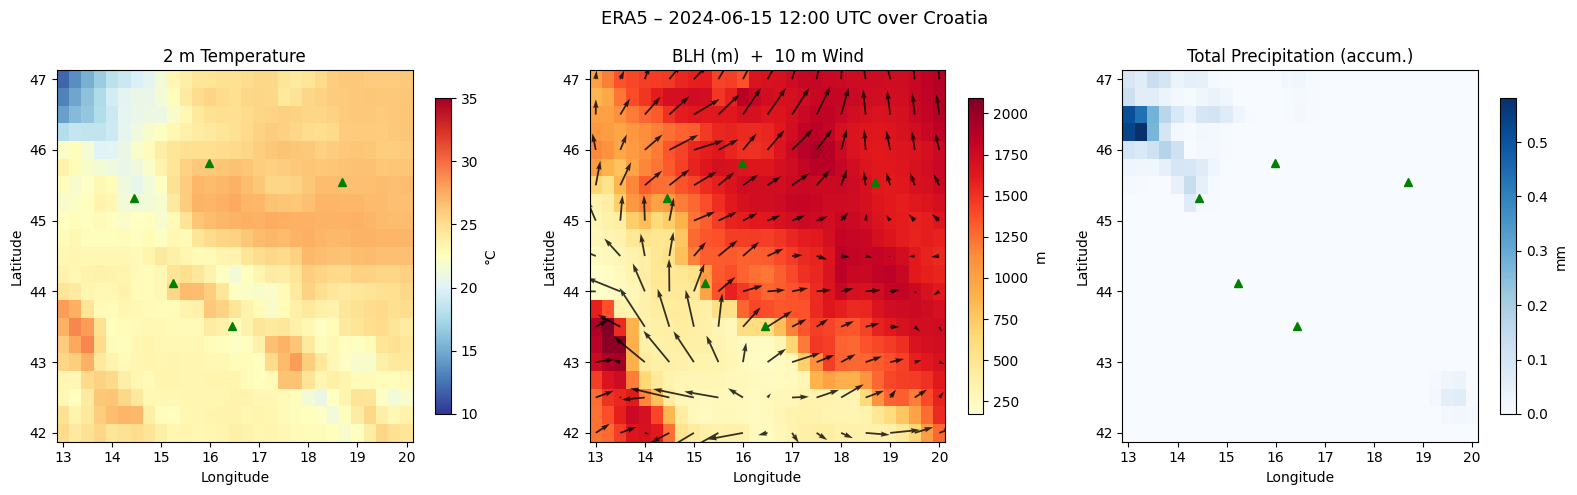

In [25]:
snap = era5.sel(valid_time="2024-06-15T12:00", method="nearest")
_stations = pd.read_csv("../../data/stations_example.csv")

lons = snap.longitude.values
lats = snap.latitude.values

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(
    f"ERA5 – {str(snap.valid_time.values)[:16].replace('T', ' ')} UTC over Croatia",
    fontsize=13,
)

# --- Panel 1: 2 m Temperature ---
t_c = snap["t2m"].values - 273.15
im0 = axes[0].pcolormesh(lons, lats, t_c, cmap="RdYlBu_r", vmin=10, vmax=35, shading="auto")
fig.colorbar(im0, ax=axes[0], label="°C", shrink=0.85)
axes[0].set_title("2 m Temperature")

# --- Panel 2: Boundary Layer Height + wind vectors ---
blh = snap["blh"].values
im1 = axes[1].pcolormesh(lons, lats, blh, cmap="YlOrRd", shading="auto")
fig.colorbar(im1, ax=axes[1], label="m", shrink=0.85)
skip = 2
axes[1].quiver(
    lons[::skip], lats[::skip],
    snap["u10"].values[::skip, ::skip],
    snap["v10"].values[::skip, ::skip],
    scale=50, width=0.005, color="k", alpha=0.8,
)
axes[1].set_title("BLH (m)  +  10 m Wind")

# --- Panel 3: Total precipitation (m → mm) ---
tp_mm = snap["tp"].values * 1000
im2 = axes[2].pcolormesh(lons, lats, tp_mm, cmap="Blues", vmin=0, shading="auto")
fig.colorbar(im2, ax=axes[2], label="mm", shrink=0.85)
axes[2].set_title("Total Precipitation (accum.)")

# Station markers on every panel
for ax in axes:
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    for _, row in _stations.iterrows():
        ax.plot(row.lon, row.lat, "g^", ms=6, zorder=5)

plt.tight_layout()
plt.show()


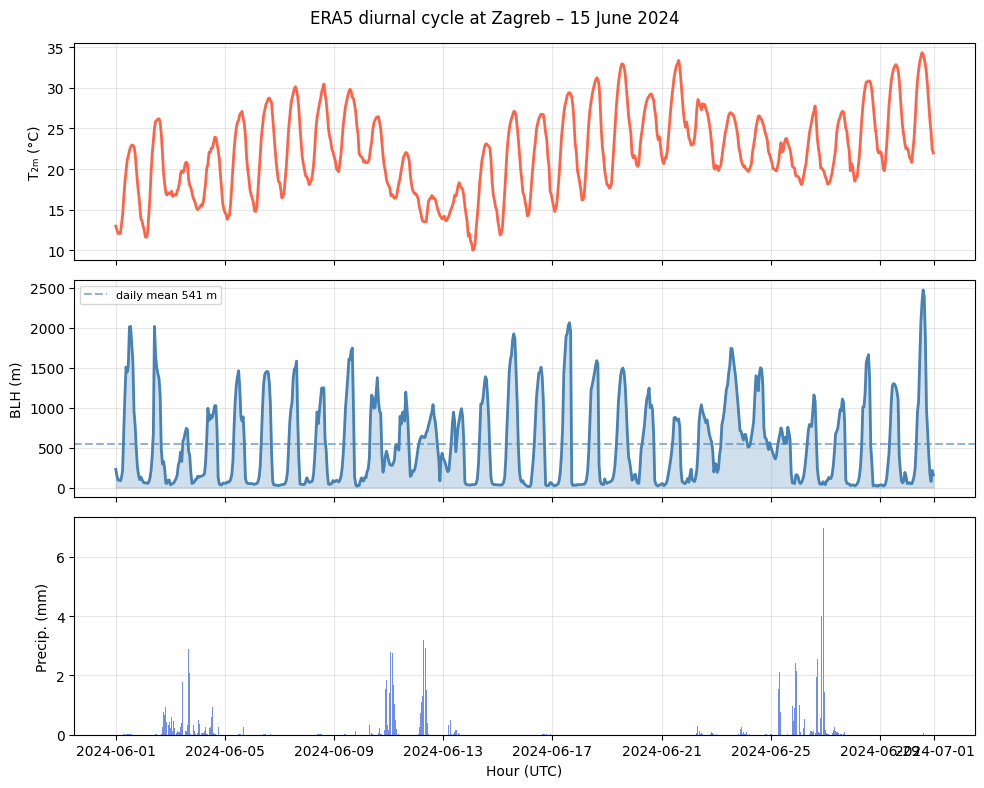


Zagreb summary — Jun 2024:
  T₂ₘ  :  min=10.0°C   max=34.3°C
  BLH  :  min=13 m   max=2474 m   (noon ≈ 2013 m)
  Rain :  peak 6.989 mm  (accumulated to that hour)


In [26]:
zagreb_lat, zagreb_lon = 45.815, 15.982

t_zg   = era5["t2m"].sel(latitude=zagreb_lat, longitude=zagreb_lon, method="nearest") - 273.15
blh_zg = era5["blh"].sel(latitude=zagreb_lat, longitude=zagreb_lon, method="nearest")
tp_zg  = era5["tp"].sel(latitude=zagreb_lat, longitude=zagreb_lon, method="nearest") * 1000

hours = pd.to_datetime(era5.valid_time.values)

fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
fig.suptitle("ERA5 diurnal cycle at Zagreb – 15 June 2024", fontsize=12)

axes[0].plot(hours, t_zg, color="tomato", linewidth=2)
axes[0].set_ylabel("T₂ₘ (°C)")
axes[0].grid(True, alpha=0.3)

axes[1].fill_between(hours, blh_zg, alpha=0.25, color="steelblue")
axes[1].plot(hours, blh_zg, color="steelblue", linewidth=2)
axes[1].axhline(float(blh_zg.mean()), color="steelblue", linestyle="--",
                alpha=0.6, label=f"daily mean {float(blh_zg.mean()):.0f} m")
axes[1].set_ylabel("BLH (m)")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

axes[2].bar(hours, tp_zg, color="royalblue",
            width=pd.Timedelta("50min"), align="center", alpha=0.75)
axes[2].set_ylabel("Precip. (mm)")
axes[2].set_xlabel("Hour (UTC)")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nZagreb summary — Jun 2024:")
print(f"  T₂ₘ  :  min={float(t_zg.min()):.1f}°C   max={float(t_zg.max()):.1f}°C")
print(f"  BLH  :  min={float(blh_zg.min()):.0f} m   max={float(blh_zg.max()):.0f} m"
      f"   (noon ≈ {float(blh_zg.isel(valid_time=12)):.0f} m)")
print(f"  Rain :  peak {float(tp_zg.max()):.3f} mm  (accumulated to that hour)")


## Urban Context: Copernicus Urban Atlas for Zagreb

Knowing *where* PM₂.₅ is elevated is useful; knowing *what land use lies underneath* is more useful still. The **Copernicus Urban Atlas Land Cover/Land Use 2021** provides a detailed land-use and land-cover map for every EU/EEA Functional Urban Area, including Grad Zagreb.

**File:** `CLMS_UA_LCU_S2021_V025ha_HR001L2_GRAD_ZAGREB_03035_V01_R01_20250321.fgb` (approximately 192 MB).

**Procedure for preparing the file** (if not already completed):

1. Log in at <https://land.copernicus.eu/en/user-corner/my-account>.
2. Search for **Urban Atlas Land Cover/Land Use 2021**, and select the Zagreb FGB tile.
3. Submit the download request. You will receive an electronic mail notification when the ZIP archive is ready.
4. Download the ZIP archive, and then execute the following command from the `scripts/` folder:

   ```bash
   python prepare_urban_atlas.py --zip C:\path\to\downloaded.zip
   ```

The FGB file contains polygons with a `code_2021` attribute that encodes the Urban Atlas class (for example, 11100 denotes Continuous urban fabric, 12100 denotes Industrial/commercial, 31000 denotes Forests, and so forth).

In the cells that follow, the notebook will:

1. Load the FlatGeobuf file using **GeoPandas**.
2. Plot the land-use classes covering Zagreb.
3. Overlay the CAMS PM₂.₅ snapshot to illustrate the relationship between the satellite signal and the urban fabric.


In [27]:
UA_PATH = Path("../../data/CLMS_UA_LCU_S2021_V025ha_HR001L2_GRAD_ZAGREB_03035_V01_R01_20250321.fgb")

if gpd is None:
    raise ImportError(
        "geopandas is required for this section.\n"
        "Install it with:  pip install geopandas"
    )

if not UA_PATH.exists():
    raise FileNotFoundError(
        f"\nMissing Urban Atlas file: {UA_PATH}\n\n"
        "Prepare it by running from the scripts/ folder:\n"
        "    python prepare_urban_atlas.py --zip C:\\path\\to\\downloaded.zip\n"
    )

print("Loading Urban Atlas FGB (may take a moment for a 192 MB file) …")
ua = gpd.read_file(UA_PATH)
print(f"Loaded {len(ua):,} polygons | CRS: {ua.crs}")
print(f"Columns: {list(ua.columns)}")

CODE_COL = next((c for c in ua.columns if c.startswith("code_")), None)
if CODE_COL is None:
    raise ValueError("Cannot find a 'code_*' column in the Urban Atlas file.")
print(f"Using land-cover column: {CODE_COL}")
ua.head()


Loading Urban Atlas FGB (may take a moment for a 192 MB file) …
Loaded 62,279 polygons | CRS: EPSG:3035
Columns: ['country', 'fua_name', 'fua_code', 'code_2021', 'class_2021', 'prod_date', 'identifier', 'perimeter', 'area', 'comment', 'geometry']
Using land-cover column: code_2021


,country,fua_name,fua_code,code_2021,class_2021,prod_date,identifier,perimeter,area,comment,geometry
0,HR,Grad Zagreb,HR001L2,12220,Other roads and associated land,2025-09,35110-HR001L2,820.866185,2426.685341,None,"MULTIPOLYGON (((4834310.615 2519275.231, 48343..."
1,HR,Grad Zagreb,HR001L2,21000,Arable land (annual crops),2025-09,48506-HR001L2,744.470847,31538.203639,None,"MULTIPOLYGON (((4834317.335 2519289.406, 48343..."
2,HR,Grad Zagreb,HR001L2,21000,Arable land (annual crops),2025-09,48461-HR001L2,308.100466,1038.617895,None,"MULTIPOLYGON (((4833056.985 2519205.005, 48330..."
3,HR,Grad Zagreb,HR001L2,12210,Fast transit roads and associated land,2025-09,34950-HR001L2,5138.555337,66365.328917,None,"MULTIPOLYGON (((4833064.183 2519220.285, 48330..."
4,HR,Grad Zagreb,HR001L2,31000,Forests,2025-09,61147-HR001L2,6943.291926,893650.117050,None,"MULTIPOLYGON (((4832452.272 2518632.693, 48324..."


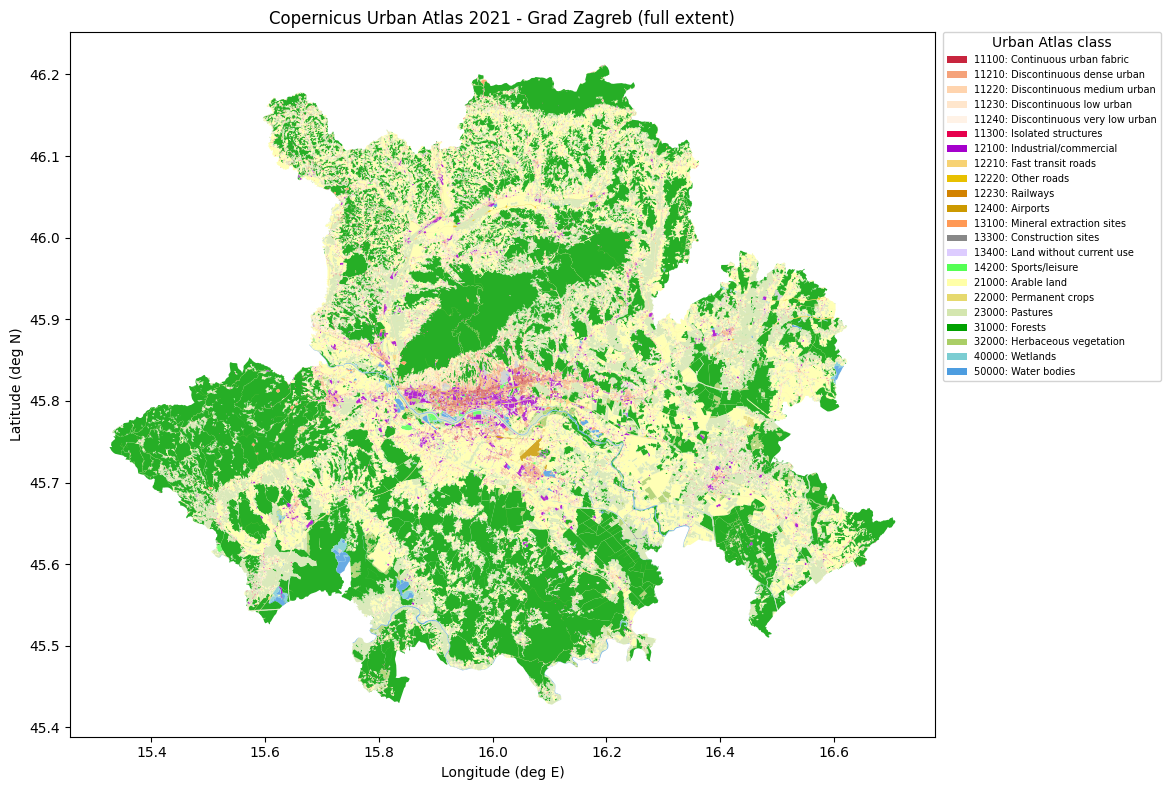

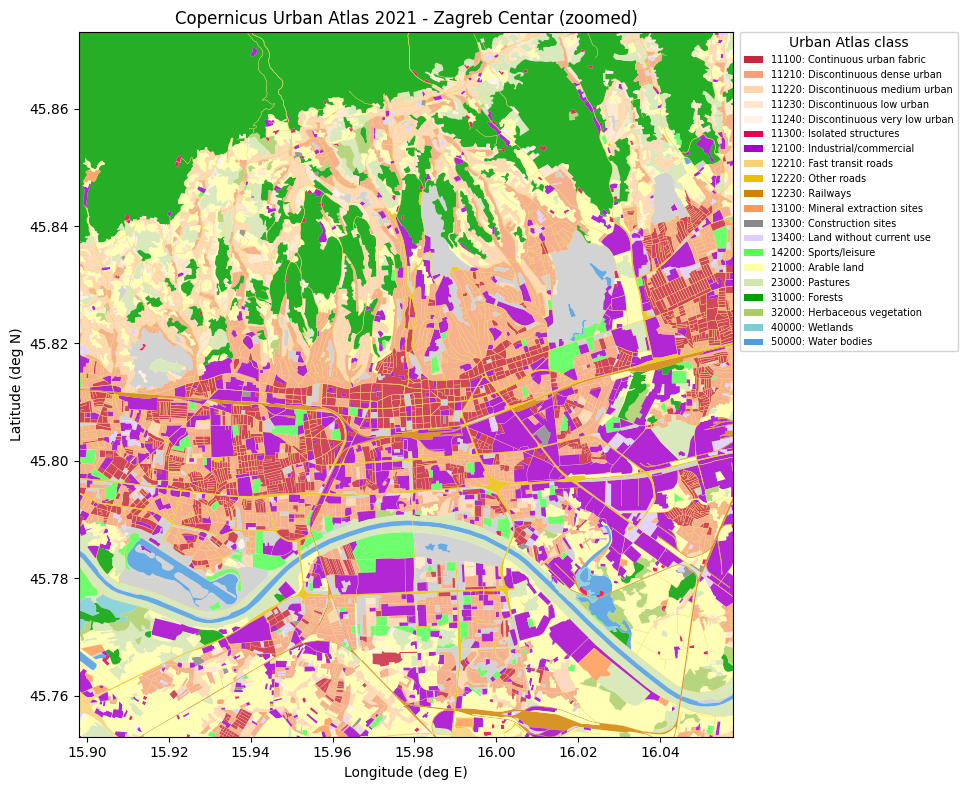

In [32]:
UA_COLORS = {
    # Artificial surfaces
    11100: ("#c8253e", "Continuous urban fabric"),
    11210: ("#f5a27a", "Discontinuous dense urban"),
    11220: ("#ffd4ae", "Discontinuous medium urban"),
    11230: ("#ffe6cc", "Discontinuous low urban"),
    11240: ("#fff2e6", "Discontinuous very low urban"),
    11300: ("#e6004d", "Isolated structures"),
    12100: ("#a500cc", "Industrial/commercial"),
    12210: ("#f7d273", "Fast transit roads"),
    12220: ("#e8c000", "Other roads"),
    12230: ("#d28200", "Railways"),
    12300: ("#6dc3c3", "Port areas"),
    12400: ("#cc9900", "Airports"),
    13100: ("#ff9955", "Mineral extraction sites"),
    13300: ("#888888", "Construction sites"),
    13400: ("#ddccff", "Land without current use"),
    14100: ("#aaffaa", "Green urban areas"),
    14200: ("#55ff55", "Sports/leisure"),
    # Agricultural
    21000: ("#ffffa8", "Arable land"),
    22000: ("#e6d96e", "Permanent crops"),
    23000: ("#d4e6af", "Pastures"),
    # Forest and semi-natural
    31000: ("#00a000", "Forests"),
    32000: ("#aace66", "Herbaceous vegetation"),
    # Wetlands & water
    40000: ("#7bcdd2", "Wetlands"),
    50000: ("#4d9de0", "Water bodies"),
}

def ua_color(code: int) -> str:
    return UA_COLORS.get(int(code), ("#cccccc", "Other"))[0]

def ua_label(code: int) -> str:
    return UA_COLORS.get(int(code), ("#cccccc", "Other"))[1]

ua_wgs = ua.to_crs(epsg=4326)
ua_wgs["color"] = ua_wgs[CODE_COL].apply(ua_color)

# --- Zagreb Centar zoom window ---
cx, cy = 15.978, 45.813
half_w, half_h = 0.08, 0.06
x0, x1 = cx - half_w, cx + half_w
y0, y1 = cy - half_h, cy + half_h

from shapely.geometry import box as shapely_box
zoom_box = shapely_box(x0, y0, x1, y1)
ua_center = ua_wgs[ua_wgs.geometry.intersects(zoom_box)]

def _make_legend(gdf, ax):
    codes = sorted(gdf[CODE_COL].unique())
    handles = [
        Patch(facecolor=UA_COLORS.get(int(c), ("#cccccc", "Other"))[0],
              label=f"{int(c)}: {ua_label(int(c))}")
        for c in codes if int(c) in UA_COLORS
    ]
    ax.legend(
        handles=handles,
        loc="upper left",
        bbox_to_anchor=(1.01, 1),
        borderaxespad=0,
        fontsize=7,
        framealpha=0.85,
        ncol=1,
        title="Urban Atlas class",
    )

# ── Plot 1: full Grad Zagreb extent ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 8))
ua_wgs.plot(ax=ax, color=ua_wgs["color"], linewidth=0, alpha=0.85)

ax.set_title("Copernicus Urban Atlas 2021 - Grad Zagreb (full extent)")
ax.set_xlabel("Longitude (deg E)")
ax.set_ylabel("Latitude (deg N)")
_make_legend(ua_wgs, ax)
plt.tight_layout()
plt.show()

# ── Plot 2: Zagreb Centar zoom ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 8))
ua_center.plot(ax=ax, color=ua_center["color"], linewidth=0, alpha=0.85)

ax.set_xlim(x0, x1)
ax.set_ylim(y0, y1)
ax.set_title("Copernicus Urban Atlas 2021 - Zagreb Centar (zoomed)")
ax.set_xlabel("Longitude (deg E)")
ax.set_ylabel("Latitude (deg N)")
_make_legend(ua_center, ax)
plt.tight_layout()
plt.show()


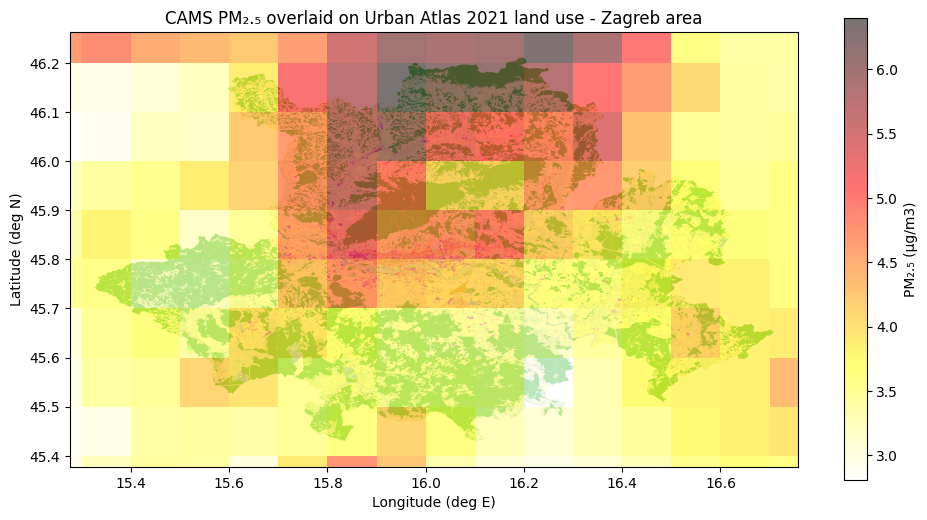

In [34]:
# Detect coord names
lon_name = next(n for n in ("longitude", "lon", "x") if n in target.coords)
lat_name = next(n for n in ("latitude", "lat", "y") if n in target.coords)

bbox = ua_wgs.total_bounds

snap = target.isel(time=0)
if float(snap[lon_name].max()) > 180:
    snap = snap.assign_coords({lon_name: ((snap[lon_name] + 180) % 360) - 180})
snap = snap.sortby([lat_name, lon_name])

snap_crop = snap.sel(
    {
        lat_name: slice(bbox[1] - 0.1, bbox[3] + 0.1),
        lon_name: slice(bbox[0] - 0.1, bbox[2] + 0.1),
    }
)

fig, ax = plt.subplots(figsize=(10, 8))

ua_wgs.plot(ax=ax, color=ua_wgs["color"].tolist(), linewidth=0, alpha=0.6)

snap_crop.plot(
    ax=ax,
    x=lon_name,
    y=lat_name,
    cmap="hot_r",
    alpha=0.55,
    cbar_kwargs={
        "label": f"PM\u2082.\u2085 ({snap.attrs.get('units', '?')})",
        "shrink": 0.6,
    },
)

ax.set_title("CAMS PM\u2082.\u2085 overlaid on Urban Atlas 2021 land use - Zagreb area")
ax.set_xlabel("Longitude (deg E)")
ax.set_ylabel("Latitude (deg N)")
ax.set_xlim(bbox[0] - 0.05, bbox[2] + 0.05)
ax.set_ylim(bbox[1] - 0.05, bbox[3] + 0.05)
ax.set_aspect("equal")

plt.tight_layout()
plt.show()

## Recapitulation

You have now traversed the complete satellite-to-station pipeline on real data over Croatia:

1. Downloaded real CAMS PM₂.₅ data from the Atmosphere Data Store.
2. Opened the NetCDF file using xarray.
3. Inspected its dimensions, variables, and global attributes.
4. Selected the target variable (PM₂.₅).
5. Reduced the data to one layer.
6. Visualised the field and confirmed that it appears reasonable.
7. Extracted values at five Croatian city stations using two distinct methods.
8. Saved the canonical long-format CSV file together with a metadata sidecar.
9. Loaded the ERA5 meteorological reanalysis for the same domain and day, plotted spatial maps (temperature, boundary layer height, wind, precipitation), and produced a diurnal time-series at Zagreb.
10. Loaded the Copernicus Urban Atlas for Zagreb and examined the land-use context of the PM₂.₅ signal.
